# this is running the estimator for the pz challenge taskset 1

In [1]:
import sys

from packaging import version
import sklearn
from sklearn.model_selection import KFold, train_test_split

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import pandas as pd
import h5py
import numpy as np

import json
import os

from matplotlib import colors
import pickle
from scipy.stats import sigmaclip
import matplotlib.gridspec as gridspec
from tensorflow.keras import layers, models, callbacks

import cnnpz_utils as cnnpz

2026-09-11 09:03:34.424816: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-11 09:03:34.424878: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-11 09:03:34.427096: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-11 09:03:34.439617: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 09:03:35.756384: W tensorflow/compiler/tf2

# predefined functions

## Load training and test data, filter curves

In [2]:
saveroot = "/pscratch/sd/q/qhang/pz_datachllenge_data/"
sims = ["cardinal","flagship"]
Yrs = [1, 10]
test_dataset_taskset1 = {}
for sim in sims:
    test_dataset_taskset1[sim] = {}
    for Yr in Yrs:
        fname = saveroot + f"pz_challenge_taskset_1_{sim}_test_{Yr}yr.hdf5"
        with h5py.File(fname, 'r') as f:
            data = {key: f[key][:] for key in f.keys()}
        test_dataset_taskset1[sim][Yr] = pd.DataFrame(data)

train_dataset_taskset1 = {}
for sim in sims:
    train_dataset_taskset1[sim] = {}
    for Yr in Yrs:
        fname = saveroot + f"pz_challenge_taskset_1_{sim}_training_{Yr}yr.hdf5"
        with h5py.File(fname, 'r') as f:
            data = {key: f[key][:] for key in f.keys()}
        train_dataset_taskset1[sim][Yr] = pd.DataFrame(data)

In [3]:
data.keys()

dict_keys(['dec', 'mag_H_roman', 'mag_H_roman_err', 'mag_J_roman', 'mag_J_roman_err', 'mag_Y_roman', 'mag_Y_roman_err', 'mag_g_lsst', 'mag_g_lsst_err', 'mag_i_lsst', 'mag_i_lsst_err', 'mag_r_lsst', 'mag_r_lsst_err', 'mag_u_lsst', 'mag_u_lsst_err', 'mag_y_lsst', 'mag_y_lsst_err', 'mag_z_lsst', 'mag_z_lsst_err', 'object_id', 'ra', 'redshift'])

In [4]:
# get the LSST and roman filter curves:
filter_root = "/global/homes/q/qhang/desc/rail_base/src/rail/examples_data/estimation_data/data/FILTER/"

wave = {
    "Y":106,
    "J":129,
    "H":158,
}
lsst_filter_curves = {}
roman_filter_curves = {}
for b in "ugrizy":
  lsst_filter_curves[b] = np.loadtxt(filter_root + f'DC2LSST_{b}.res')

for b in "YJH":
  roman_filter_curves[b] = np.loadtxt(filter_root + f'roman_{b}{wave[b]}.res')

# define the wavelength grid
# to begin with, use blocks rather than filter curves
lambda_min = lsst_filter_curves['u'][:,0].min()
lambda_max = roman_filter_curves['H'][:,0].max()
print(lambda_min,lambda_max)

lambda_array = np.linspace(lambda_min,lambda_max,31)
# now let's conver filter curves to blocks: here let's also ignore the big Y band as it overlaps with the y band

3000.0 18650.0


### Transform data, make X_train, Y_train, and test dataset, variants of this dataset

In [5]:
bin_edges = {}
for b in "ugrizyJH":
  if b not in "JH":
    bin_edges[b] = cnnpz.get_bin_edges(lsst_filter_curves[b][:,0])
  else:
    bin_edges[b] = cnnpz.get_bin_edges(roman_filter_curves[b][:,0])
new_edges = lambda_array

rebinned_filters={}
for b in "ugrizyJH":
  if b not in "JH":
    counts = lsst_filter_curves[b][:,1]
  else:
    counts = roman_filter_curves[b][:,1]
  rebinned_filters[b] = cnnpz.rebin_filter(bin_edges[b], counts, new_edges)

lambda_array_cen = (new_edges[1:] + new_edges[:-1])/2
dlambda = new_edges[1] - new_edges[0]
#for b in "ugrizyJH":
#  plt.plot(lambda_array_cen, rebinned_filters[b],'.-')

# further convert this to blocks:
# let's take 1 when the current filter value is > next filter
filter_blocks={}
bands = "ugrizyJH"
for i, b in enumerate("ugrizyJ"):
  if i>0:
    filter_blocks[b] = (rebinned_filters[b] >= rebinned_filters[bands[i+1]]) & (rebinned_filters[b] > rebinned_filters[bands[i-1]])
  else:
    filter_blocks[b] = (rebinned_filters[b] > rebinned_filters[bands[i+1]])
filter_blocks['H'] = (rebinned_filters['H'] > rebinned_filters['J']) & (rebinned_filters['H'] > rebinned_filters['y'])

# Cardinal Y1

In [6]:
# let's start with Carindal Y1 T1:
training_data = train_dataset_taskset1['cardinal'][1]
test_data = test_dataset_taskset1['cardinal'][1]

# now split training and validation set:
X, Y = cnnpz.transform_data_to_XY(training_data, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test, _ = cnnpz.transform_data_to_XY(test_data, lambda_array_cen, filter_blocks, apply_stretch = False, missingY=True)

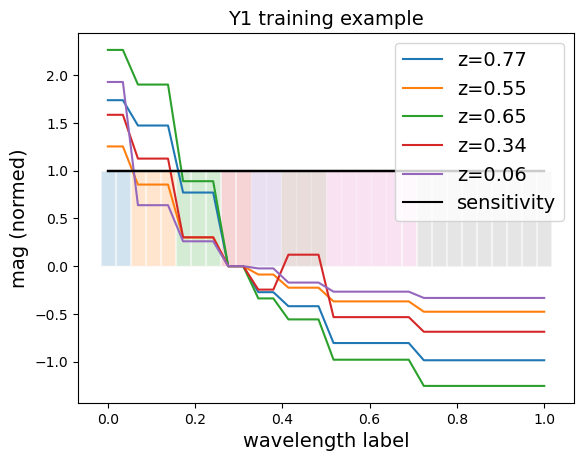

In [7]:
cnnpz.visualize_the_data(X, Y, lambda_array_cen, filter_blocks, title="Y1 training example")

# training ensemble model

In [27]:
trained_models, histories = cnnpz.train_ensembles(build_model, X, Y)


--- Fold 1/5 ---


2026-07-13 03:43:30.090020: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/100
313/313 - 13s - loss: 0.3313 - val_loss: 0.1503 - lr: 0.0010 - 13s/epoch - 42ms/step
Epoch 2/100
313/313 - 12s - loss: 0.1479 - val_loss: 0.1154 - lr: 0.0010 - 12s/epoch - 38ms/step
Epoch 3/100
313/313 - 12s - loss: 0.1137 - val_loss: 0.0927 - lr: 0.0010 - 12s/epoch - 38ms/step
Epoch 4/100
313/313 - 12s - loss: 0.1017 - val_loss: 0.0897 - lr: 0.0010 - 12s/epoch - 38ms/step
Epoch 5/100
313/313 - 11s - loss: 0.0957 - val_loss: 0.0710 - lr: 0.0010 - 11s/epoch - 37ms/step
Epoch 6/100
313/313 - 11s - loss: 0.0911 - val_loss: 0.0664 - lr: 0.0010 - 11s/epoch - 36ms/step
Epoch 7/100
313/313 - 11s - loss: 0.0908 - val_loss: 0.0764 - lr: 0.0010 - 11s/epoch - 36ms/step
Epoch 8/100
313/313 - 11s - loss: 0.0856 - val_loss: 0.0697 - lr: 0.0010 - 11s/epoch - 36ms/step
Epoch 9/100
313/313 - 11s - loss: 0.0850 - val_loss: 0.0606 - lr: 0.0010 - 11s/epoch - 36ms/step
Epoch 10/100
313/313 - 12s - loss: 0.0819 - val_loss: 0.0606 - lr: 0.0010 - 12s/epoch - 37ms/step
Epoch 11/100
313/313 - 11s - 

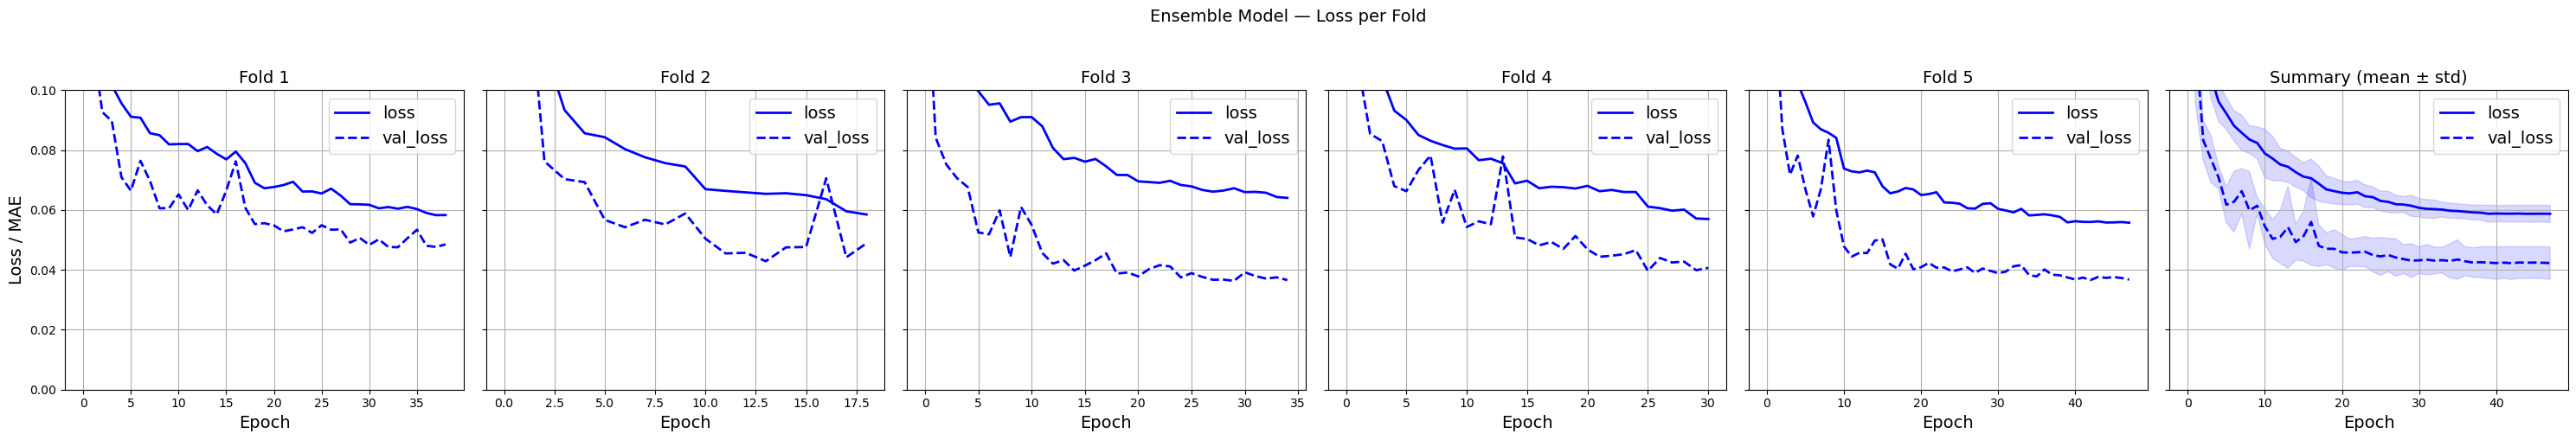

In [28]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.1))

In [30]:
# Final prediction on test set
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test)

625/625 [==============================] - 2s 3ms/step


In [31]:
y_pred_ensemble2, y_pred_STD2 = cnnpz.ensemble_predict(trained_models, X)

3125/3125 [==============================] - 8s 3ms/step


In [45]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models"
save_dir = root + "/ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/norm_params.json


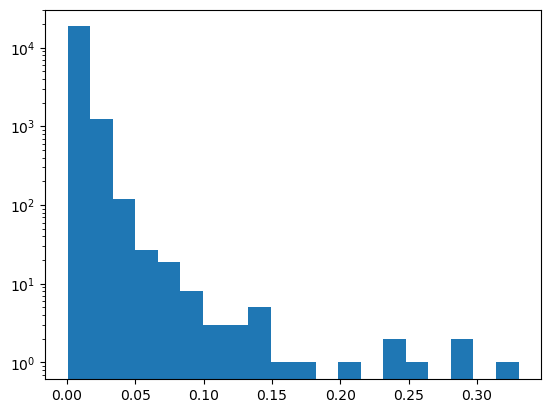

In [46]:
cc = plt.hist(y_pred_STD.flatten(), bins=20)
plt.yscale("log")

/tmp/ipykernel_1240551/2220381783.py:18: RuntimeWarning: invalid value encountered in scalar divide
  outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
/tmp/ipykernel_1240551/2220381783.py:21: RuntimeWarning: invalid value encountered in scalar divide
  abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
/tmp/ipykernel_1240551/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


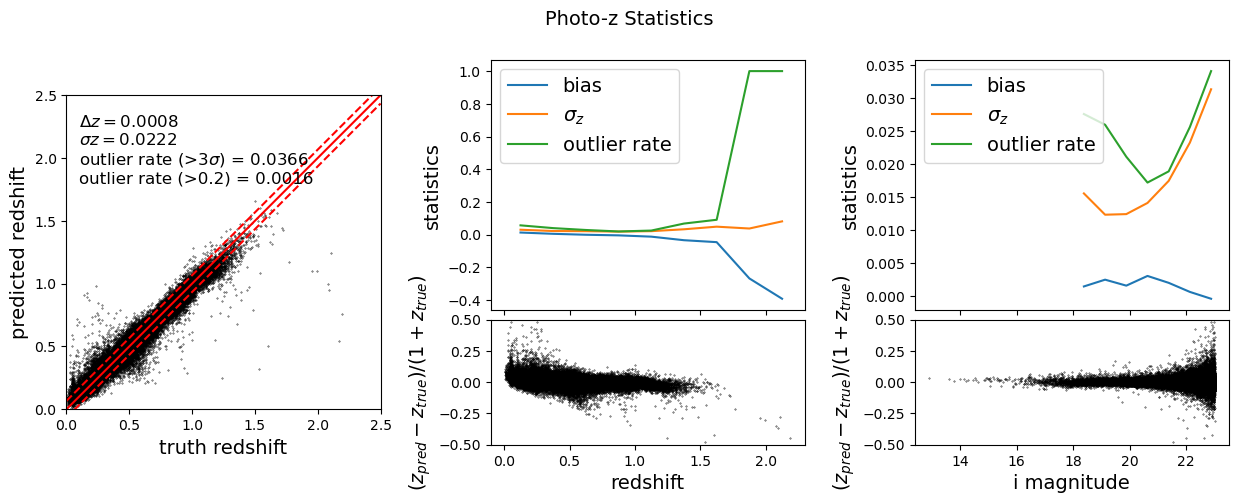

Plot saved to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y1/models/ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [53]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y, y_pred_ensemble2.flatten(), training_data['mag_i_lsst'], save=True, saveroot=fname, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y, y_pred_ensemble2.flatten(), 
           redshift_bins, imag_bins, training_data['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

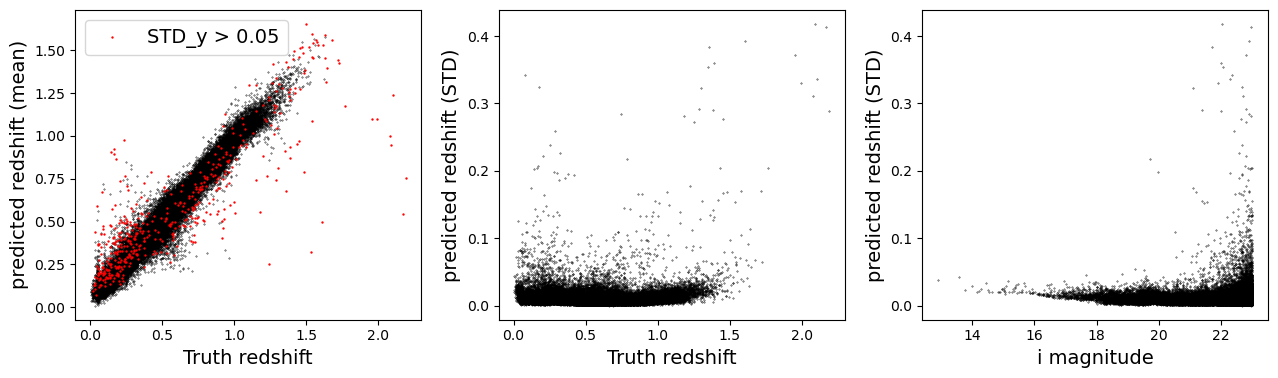

In [54]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD2.flatten() >= 0.05
plt.scatter(Y[~ind], y_pred_ensemble2.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y[ind], y_pred_ensemble2.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y, y_pred_STD2.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(training_data['mag_i_lsst'], y_pred_STD2.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

## Cardinal Y10

In [9]:
training_data = train_dataset_taskset1['cardinal'][10]
test_data = test_dataset_taskset1['cardinal'][10]

X, Y = cnnpz.transform_data_to_XY(training_data, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test, _ = cnnpz.transform_data_to_XY(test_data, lambda_array_cen, filter_blocks, apply_stretch = False, missingY=True)

In [21]:
trained_models, histories = cnnpz.train_ensembles(build_model, X, Y)


--- Fold 1/5 ---


2026-07-15 04:16:22.697680: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6635 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


Epoch 1/100


2026-07-15 04:16:24.707070: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903
2026-07-15 04:16:28.517631: I external/local_xla/xla/service/service.cc:168] XLA service 0x559f87a96f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-15 04:16:28.517656: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-07-15 04:16:28.563356: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784114188.898720 1735656 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 - 14s - loss: 0.3631 - val_loss: 0.1419 - lr: 0.0010 - 14s/epoch - 44ms/step
Epoch 2/100
313/313 - 2s - loss: 0.1290 - val_loss: 0.0849 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 3/100
313/313 - 2s - loss: 0.0948 - val_loss: 0.0556 - lr: 0.0010 - 2s/epoch - 8ms/step
Epoch 4/100
313/313 - 2s - loss: 0.0807 - val_loss: 0.0513 - lr: 0.0010 - 2s/epoch - 8ms/step
Epoch 5/100
313/313 - 2s - loss: 0.0737 - val_loss: 0.0532 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 6/100
313/313 - 2s - loss: 0.0693 - val_loss: 0.0371 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 7/100
313/313 - 2s - loss: 0.0638 - val_loss: 0.0374 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 8/100
313/313 - 2s - loss: 0.0616 - val_loss: 0.0347 - lr: 0.0010 - 2s/epoch - 8ms/step
Epoch 9/100
313/313 - 2s - loss: 0.0612 - val_loss: 0.0325 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 10/100
313/313 - 2s - loss: 0.0587 - val_loss: 0.0352 - lr: 0.0010 - 2s/epoch - 8ms/step
Epoch 11/100
313/313 - 2s - loss: 0.0593 - val_loss: 0.0420 - lr: 0.

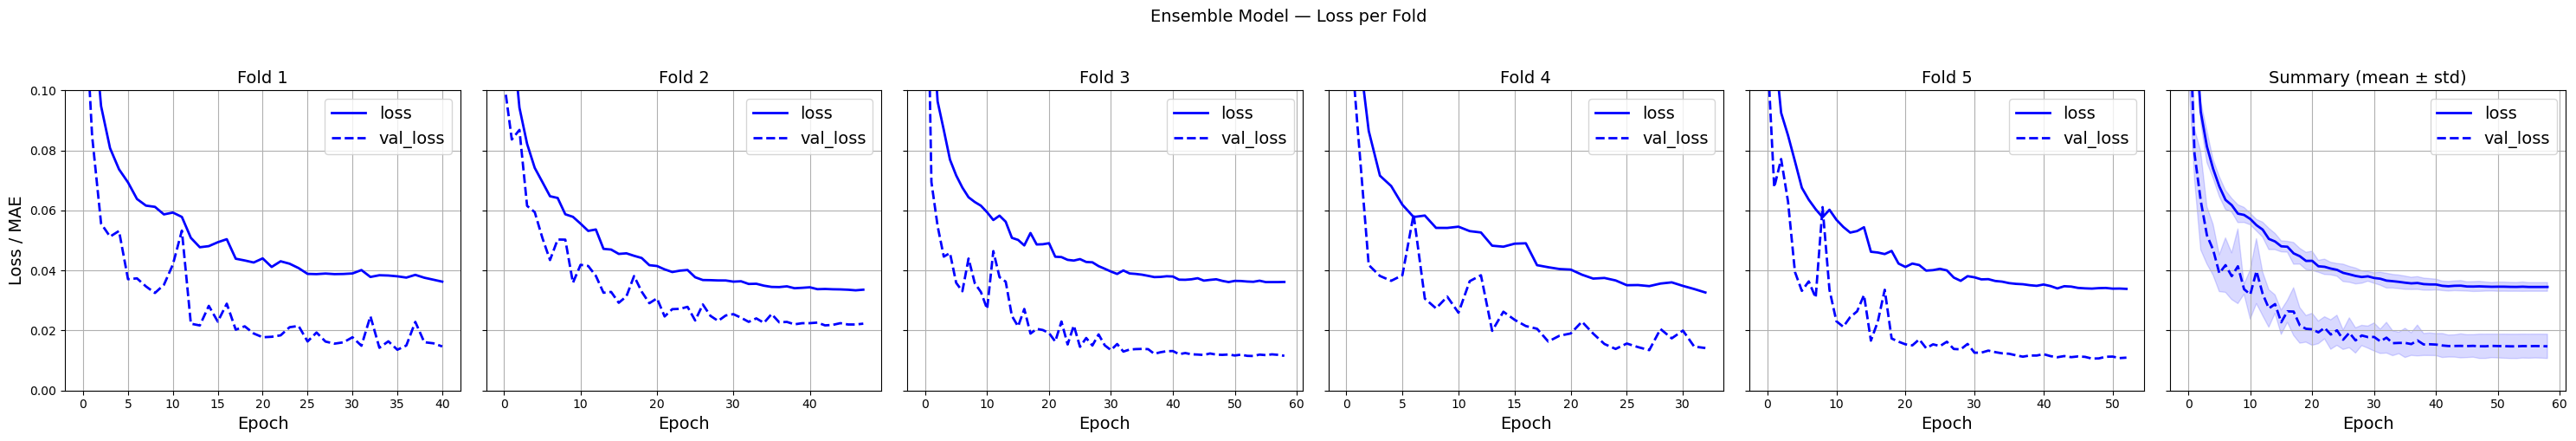

In [22]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.1))

In [23]:
y_pred_ensemble2, y_pred_STD2 = cnnpz.ensemble_predict(trained_models, X)

3125/3125 [==============================] - 7s 2ms/step


In [24]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models"
save_dir = root + "/ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

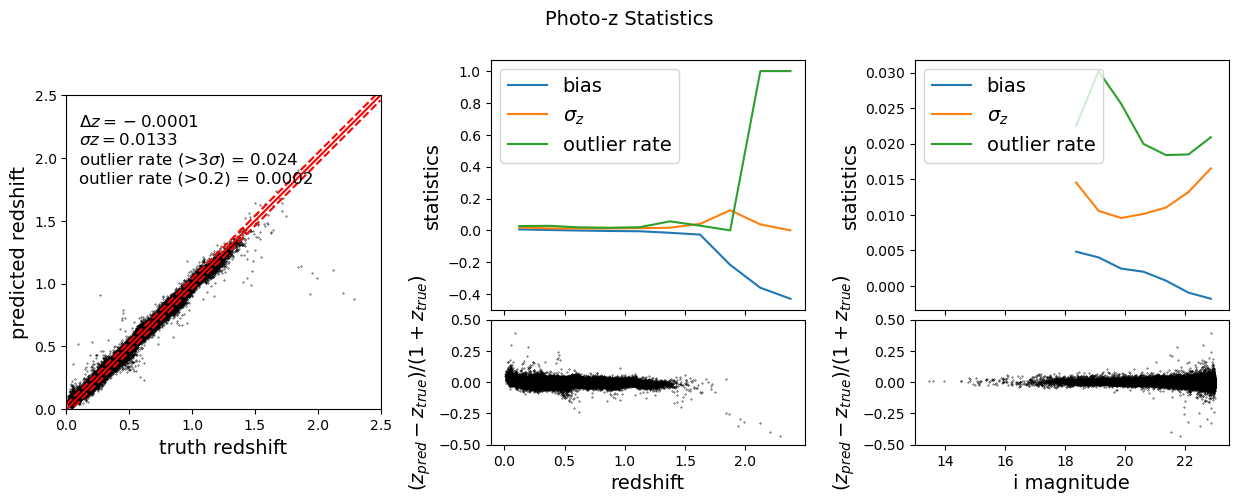

Plot saved to /pscratch/sd/q/qhang/cnnpz/PZDC/taskset1/Cardinal_Y10/models/ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [25]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y, y_pred_ensemble2.flatten(), training_data['mag_i_lsst'], save=True, saveroot=fname, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y, y_pred_ensemble2.flatten(), 
           redshift_bins, imag_bins, training_data['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

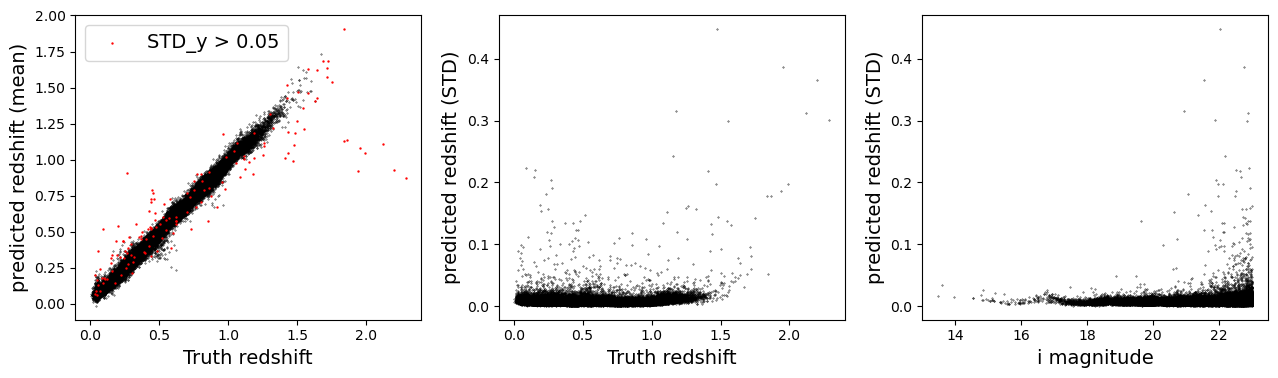

In [26]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD2.flatten() >= 0.05
plt.scatter(Y[~ind], y_pred_ensemble2.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y[ind], y_pred_ensemble2.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y, y_pred_STD2.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(training_data['mag_i_lsst'], y_pred_STD2.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

## Flagship

In [12]:
training_data = train_dataset_taskset1['flagship'][1]
test_data = test_dataset_taskset1['flagship'][1]

X, Y = cnnpz.transform_data_to_XY(training_data, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test, _ = cnnpz.transform_data_to_XY(test_data, lambda_array_cen, filter_blocks, apply_stretch = False, missingY=True)